<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_10)_seq2seq_nmt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 10)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### Neural Machine Translation with Seq2Seq and Attention

This notebook covers **Neural Machine Translation**, from foundational Seq2Seq models to attention mechanisms and decoding strategies.

- **Neural Machine Translation (NMT)** is a neural networks based approach for translating text from one language to another.
- Unlike traditional rule-based translation systems, NMT learns to translate by analyzing large parallel corpora of translations.

- The neural network learns patterns and relationships between languages to generate accurate translations.

### Seq2Seq Model

Seq2Seq (Sequence-to-Sequence) is a neural network architecture consisting of encoder and decoder.

**Example:** English to French translation

  "It's time for tea"  $ \qquad  \rightarrow  \qquad   $ "C'est l'heure du thé"

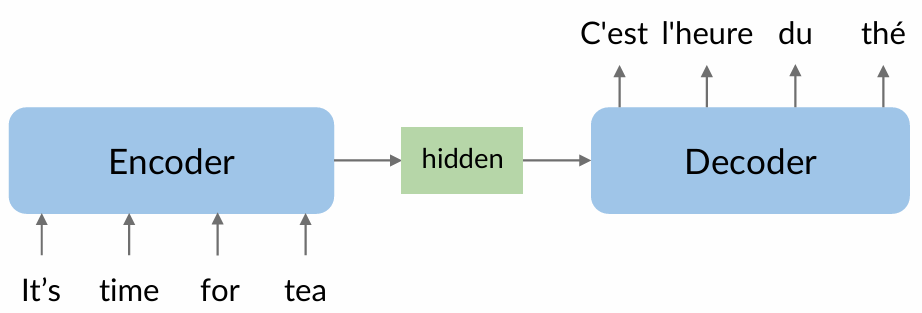

**Key Characteristics:**
1. **Introduced by Google in 2014** - Revolutionary approach to machine translation
2. **Maps variable-length sequences to fixed-length memory** - Compresses input into a context vector
3. **Inputs and outputs can have different lengths** - English and French sentences aren't the same length
4. **Uses LSTMs and GRUs** - To avoid vanishing and exploding gradient problems

### Seq2Seq Encoder

The encoder encodes the overall meaning of the input sequence and produces a fixed-size context vector.


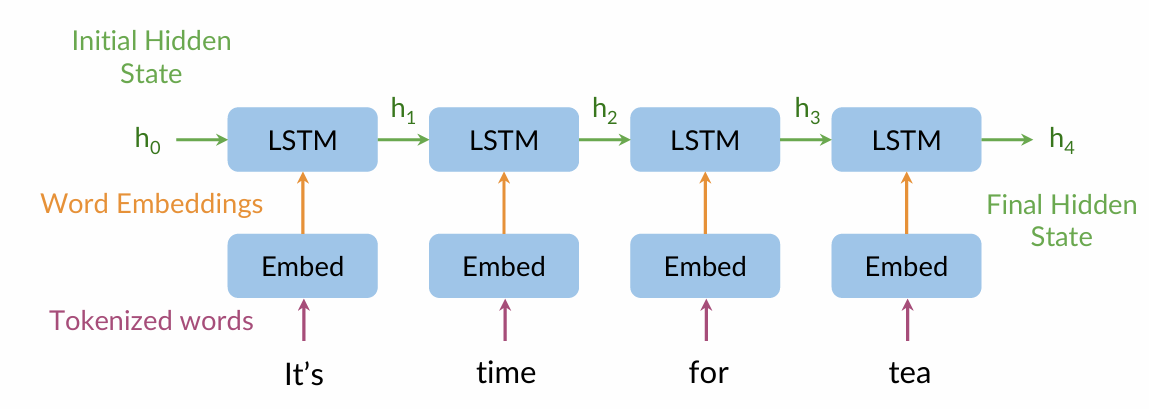

**Process:**
1. Each word is converted to an embedding vector
2. Embeddings are processed sequentially through LSTM cells
3. Each LSTM cell processes current input and previous hidden state
4. Final hidden state $h_4$ contains the complete encoded information of the entire input sentence as a fixed-size context vector.

### Seq2Seq Decoder

The decoder takes the context vector and generates the output sequence one token at a time.

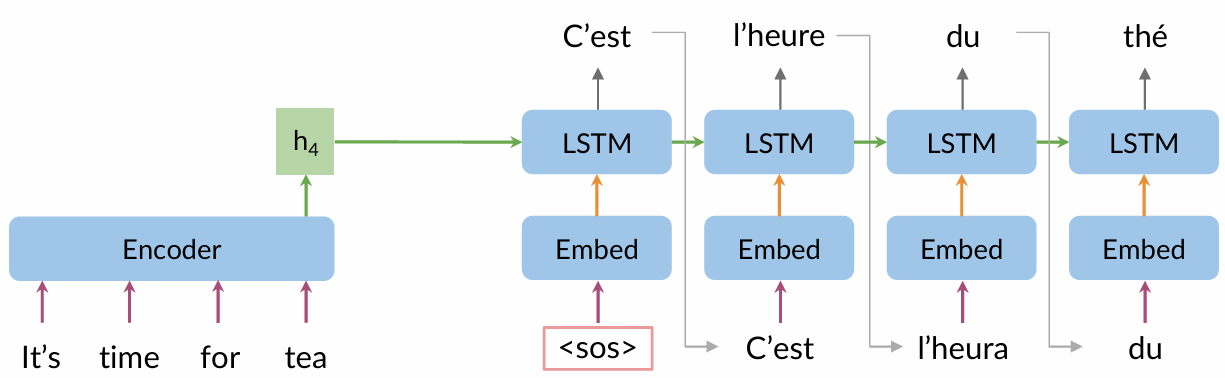

**Key Points:**
1. Decoder receives the context vector from encoder as initial hidden state
2. Starts with special token `<sos>` (start of sequence)
3. Generates one word at a time
4. Each output becomes input for next step
5. Process continues until `<eos>` (end of sequence) token is generated

### The Information Bottleneck Problem

RNNs have the structural limitation of compressing the entire history of an input sequence into a single, fixed-size hidden state vector at each time step.

- This forces the model to discard older or less prominent information, causing forgetting in long sequences.
- The fixed-size hidden state of encoder is problematic and creates an **information bottleneck**.

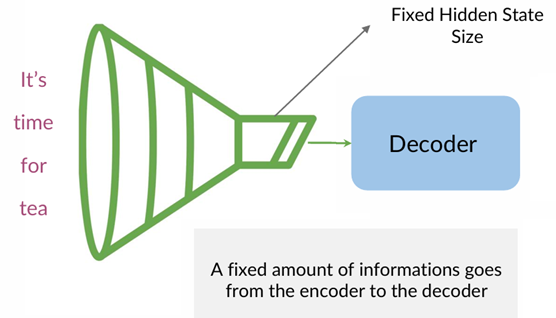

#### Problems due to information bottleneck

1. **Loss of Information**: Long input sequences get compressed into a fixed vector
2. **Difficulty with Long Sequences**: Performance degrades as input length increases
3. **All Words Treated Equally**: The decoder can't focus on relevant parts of input
4. **Performance drops significantly** with sentences longer than 15-20 words


### Attention Mechanism: The Solution to Information Bottleneck

Attention uses all the hidden encoder states and combines them using weights from the **decoder**.

- Attention allows the decoder to **focus on relevant parts** of the input while generating each output word.

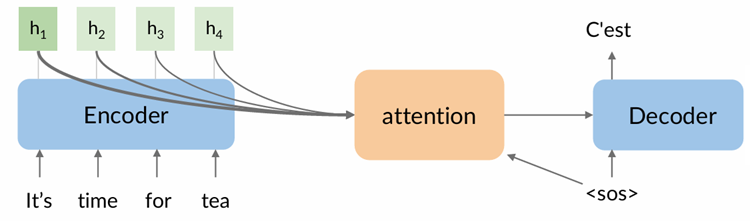



```

```



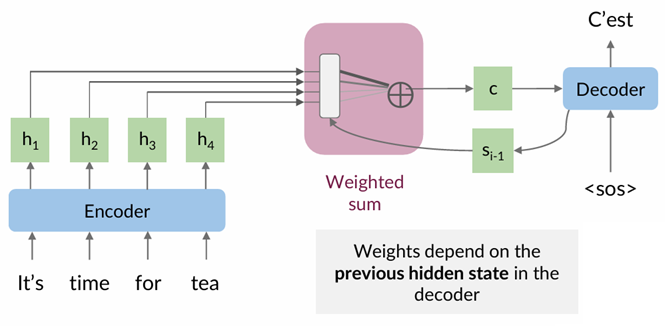



- Dzmitry Bahdanau's breakthrough paper in 2014, "[Neural Machine Translation by Jointly Learning to Align and Translate](https://arxiv.org/pdf/1409.0473)," introduced the Attention Mechanism to sequence models, enabling networks to dynamically "focus" on relevant parts of a source sentence during translation.

### Attention Layer

A layer between encoder and decoder so that the model can focus on specific hidden states at every step.


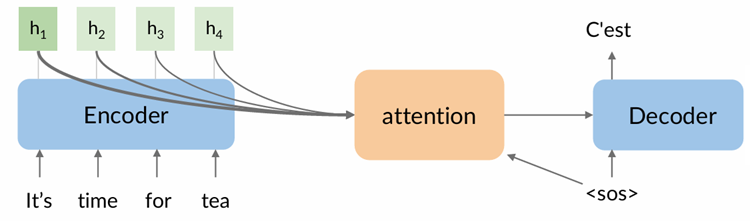



### Details of the Attention Layer

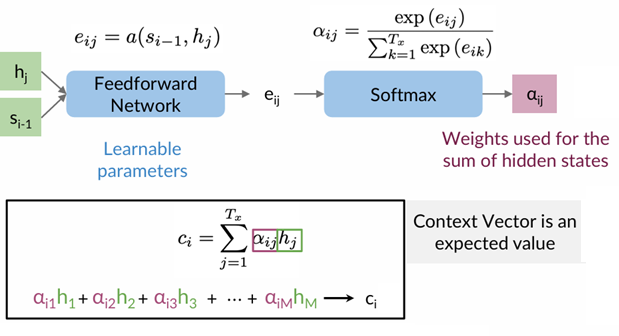



> The feedforward network to compute attention receives decoder hidden state $s_{i−1}$ and all of encoder hidden states $h_j$ as inputs to generate $e_{ij}$ for every encoder word.

### Details of Attention Layer
**Key Formulae:**

- $e_{ij} = a(s_{i-1}, h_j)$: alignment score (how much should we focus on position $j$?)
- $α_{ij} = \text{exp}(e_{ij}) / \sum_{k=1}^T \text{exp}(e_{ik})$: Attention weight (probability distribution over source positions)
- $c_i = \sum_{j=1}^T α_{ij} * h_j$: Context vector (weighted average of all encoder hidden states)

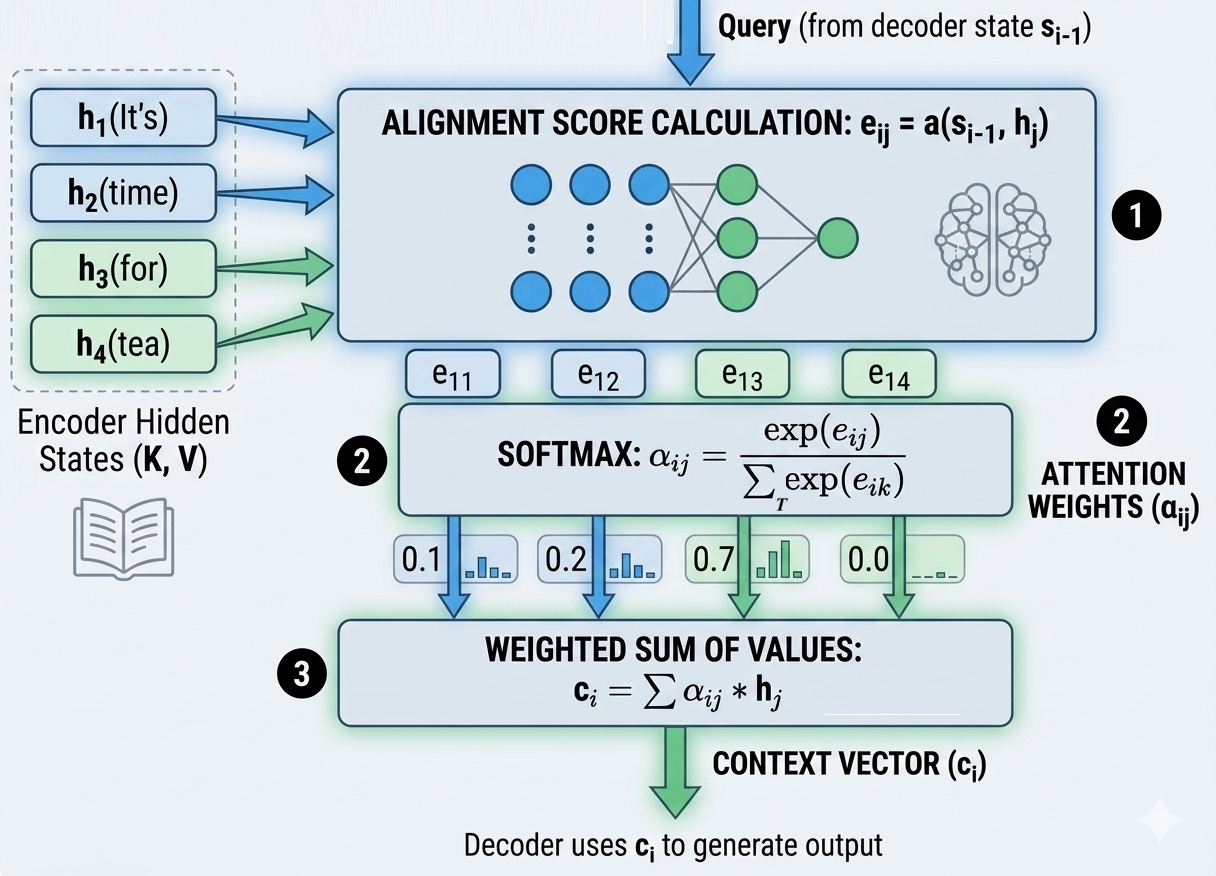

### Details of Attention Layer

**Components of the Attention Mechanism: Query, Keys, and Values**

1. **Query (Q)**: Represents what we're looking for. Here, it is decoder's hidden state $s_{i-1}$

2. **Keys (K)**: Each of encoder's hidden states $h_1, h_2, ..., h_T$

3. **Values (V)**: Information to be weighted and summed related to encoder's hidden states $h_1, h_2, ..., h_T$

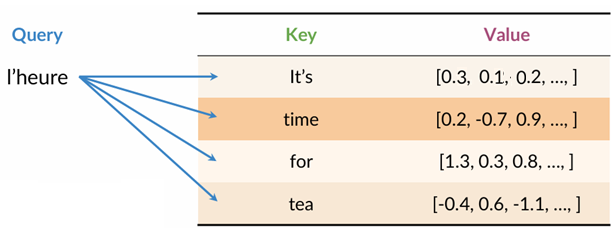

### NMT Model with Attention: Alignment Weights

Similar words have large weights.

- ░ = high attention (strong alignment)
- █ = low attention (weak alignment)

Lighter cells show which English words are most important
for generating each French word.

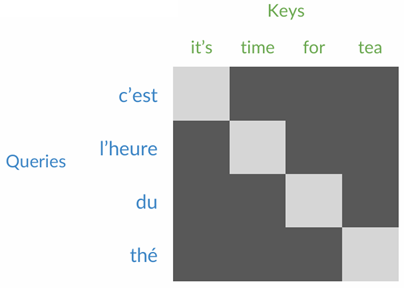



### Another example of alignment weights

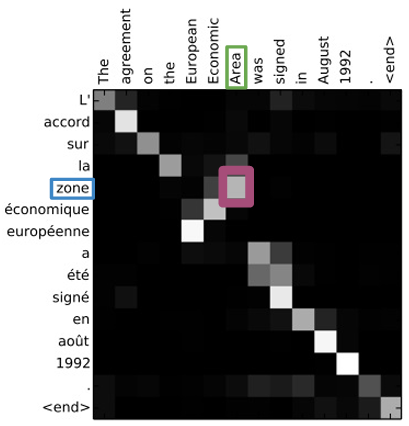

### Benefits of using Attention

1. **No Information Bottleneck**: Decoder can directly access all encoder hidden states
2. **Dynamic Focus**: Automatically learns which parts to focus on for each output
3. **Better Long-Sequence Performance**: Can handle longer sentences effectively
4. **Interpretability**: Attention weights show which input words contributed to each output


### Query, Key, Value ($QKV$) Framework

The Queries, Keys, and Values framework is fundamental to attention mechanisms for transformer model: [Attention Is All You Need paper by Vaswani et al in 2017](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)

**The paper uses Scaled Dot-Product Attention**

$$
\text{Attention}(Q,K,V)
=
\text{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$



Where:
- $Q$: Query matrix ($m × d_k$)
- $K$: Key matrix ($n × d_k$)
- $V$: Value matrix ($n × d_v$)
- $d_k$: Dimension of keys
- $m$: Sequence length of queries from decoder (output length)
- $n$: Sequence length of keys/values (source positions to attend to)

**Why divide by $√d_k$?**
- Prevents dot products from becoming too large
- Keeps softmax gradients stable to improve training stability

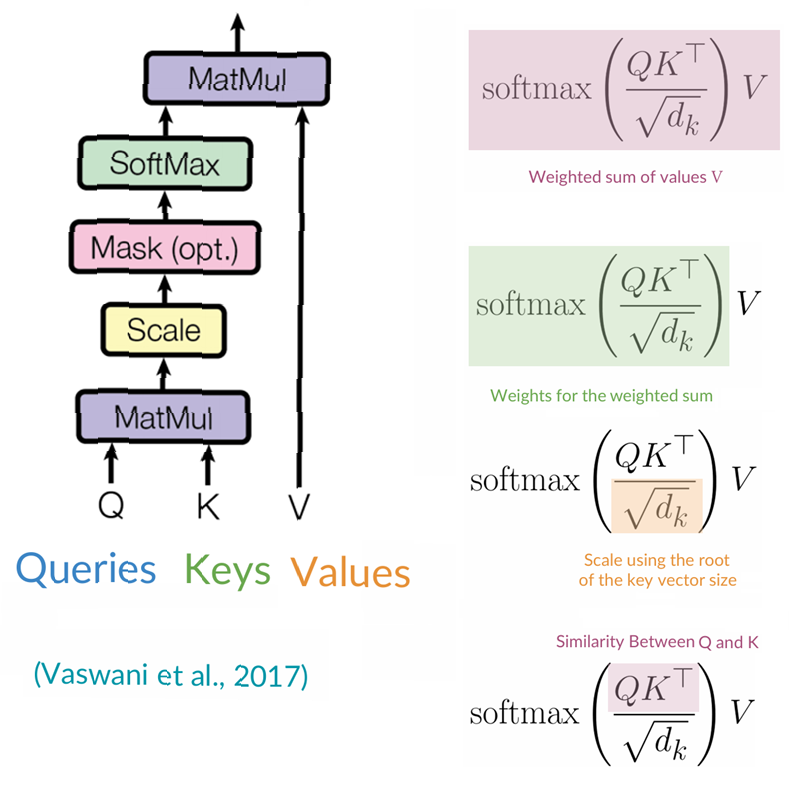

### Attention Computation Process - Numerical Example

#### The Scaled Dot-Product Attention Computation Example
Suppose we have the sentence:

| Word | Key Vector |
|--------|------------|
| It's | k₁ = [0.3, 0.1, 0.2] |
| time | k₂ = [0.2, -0.7, 0.9] |
| for | k₃ = [1.3, 0.3, 0.8] |
| tea | k₄ = [-0.4, 0.6, -1.1] |

Current Query:

```text
q = [0.5, -0.2, 0.8]
```

Key dimension:
```text
d_k = 3
```


---

### Step 1: Compute Similarity Scores (Q · Kᵀ)

#### For "It's"

$$
q \cdot k_1
=
0.5(0.3)+(-0.2)(0.1)+0.8(0.2)
$$

$$
=0.15-0.02+0.16
$$

$$
=0.29
$$

#### For "time"

$$
q \cdot k_2
=
0.5(0.2)+(-0.2)(-0.7)+0.8(0.9)
$$

$$
=0.10+0.14+0.72
$$

$$
=0.96
$$

#### For "for"

$$
q \cdot k_3
=
0.5(1.3)+(-0.2)(0.3)+0.8(0.8)
$$

$$
=0.65-0.06+0.64
$$

$$
=1.23
$$

#### For "tea"

$$
q \cdot k_4
=
0.5(-0.4)+(-0.2)(0.6)+0.8(-1.1)
$$

$$
=-0.20-0.12-0.88
$$

$$
=-1.20
$$

#### Raw Attention Scores

$$
[0.29,\;0.96,\;1.23,\;-1.20]
$$

---

### Step 2: Scale Scores

Now scale the scores by:

$$
\sqrt{d_k}
=
\sqrt{3}
=
1.732
$$

Scaled scores:

$$
\left[
\frac{0.29}{1.732},
\frac{0.96}{1.732},
\frac{1.23}{1.732},
\frac{-1.20}{1.732}
\right]
$$

$$
=
[0.167,\;0.554,\;0.710,\;-0.693]
$$

---

### Step 3: Apply Softmax

Compute exponentials:

$$
e^{0.167}=1.182
$$

$$
e^{0.554}=1.740
$$

$$
e^{0.710}=2.034
$$

$$
e^{-0.693}=0.500
$$

Sum:

$$
Z
=
1.182+1.740+2.034+0.500
=
5.456
$$

Compute probabilities:

$$
\alpha_1
=
\frac{1.182}{5.456}
=
0.217
$$

$$
\alpha_2
=
\frac{1.740}{5.456}
=
0.319
$$

$$
\alpha_3
=
\frac{2.034}{5.456}
=
0.373
$$

$$
\alpha_4
=
\frac{0.500}{5.456}
=
0.092
$$

### Attention Weights

| Word | Weight |
|--------|---------:|
| It's | 0.217 |
| time | 0.319 |
| for | 0.373 |
| tea | 0.092 |

Verification:

$$
0.217+0.319+0.373+0.092
≈
1.00
$$

---

### Step 4: Define Value Vectors

| Word | Value Vector |
|--------|-------------|
| It's | v₁ = [0.5, 0.2] |
| time | v₂ = [0.2, -0.7] |
| for | v₃ = [1.3, 0.3] |
| tea | v₄ = [-0.4, 0.6] |

---

### Step 5: Compute Context Vector

The attention output is:

$$
c
=
0.217v_1
+
0.319v_2
+
0.373v_3
+
0.092v_4
$$

Substituting the value vectors:

$$
c
=
0.217[0.5,0.2]
+
0.319[0.2,-0.7]
+
0.373[1.3,0.3]
+
0.092[-0.4,0.6]
$$

$$
=
[0.1085,0.0434]
+
[0.0638,-0.2233]
+
[0.4849,0.1119]
+
[-0.0368,0.0552]
$$

Adding component-wise:

$$
c
=
[
0.1085+0.0638+0.4849-0.0368,
\;
0.0434-0.2233+0.1119+0.0552
]
$$

$$
=
[0.6204,\;-0.0128]
$$

Therefore, the final context vector is:

$$
\boxed{
c=[0.6204,\;-0.0128]
}
$$

---

### Interpretation

The query attended to the words with the following importance:

| Word | Attention |
|--------|---------:|
| It's | 21.7% |
| time | 31.9% |
| for | 37.3% |
| tea | 9.2% |

The model therefore retrieves information primarily from **"for"**, followed by **"time"**, then **"It's"**, and very little from **"tea"**.

The resulting context vector $c=[0.6204,\;-0.0128]$ is a weighted summary of all value vectors and becomes the output of the attention mechanism that is passed to the decoder for machine translation.

### Training Seq2Seq Neural Machine Translation Model

### 1. Data Preparation

**Key Steps:**
1. **Tokenization**: Break sentences into words/subwords
2. **Word2Ind**: Convert words to integer indices
3. **Padding**: Make all sequences same length (with zeros)
4. ** Token**: Mark end of sequence $\text{<EOS>}$ and start of target sequence for decoder $\text{<SOS>}$

Let special tokens be:
```
<PAD>: 0
<EOS>: 1
<SOS>: 2
```
**English-to-French Translation Example:**

```
English Sentence:
  "Both the ballpoint and the mechanical pencil in the series are
   equipped with a special mechanism: when the twist mechanism is
   activated, the lead is pushed forward."

Tokenized Version:
  [4546, 4, 11358, 362, 8, 4, 23326, 20104, 1745, 8210, 9641,
   5, 6, 4, 3103, 31, 2767, 30, 13, 914, 4797, 64, 196, 4,
   22474, 5, 4797, 16, 24864, 86, 20, 4, 1060, 16, 6413,
   1138, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   
   (with <EOS> and padding zeros at the end)

French Target:
  "Le stylo à bille et le porte-mine de la série sont équipés d'un
   mécanisme spécial: lorsque le mécanisme de torsion est activé,
   le plomb est poussé vers l'avant."

Tokenized Version:
  [2, 29587, 9, 18240, 8, 7, 420, 5, 3440, 3, 6, 156, 39,
   7941, 14, 19, 5548, 2648, 562, 7, 5548, 3, 23194, 18,
   20114, 10, 7, 5695, 18, 8865, 149, 12, 137, 1, 0, 0,
   0, 0, 0, 0, 0, 0, 0]

   (with <SOS>, <EOS> and padding zeros at the end)
```




### Training Seq2Seq Neural Machine Translation Model

#### 2. Training Overview

```
Training Process:

1. FORWARD PASS
   ┌─────────────────────────────────┐
   │ Input: "It's time for tea"      │
   │ Target: "C'est l'heure du thé"  │
   └──────────────┬──────────────────┘
                  ↓
          Encoder Processes Input
                  ↓
          Context Vector Generated
                  ↓
          Decoder Generates Output
                  ↓

2. LOSS COMPUTATION
   Compare predictions with targets
   Loss = -log(P(target | input))
   
3. BACKWARD PASS
   Compute gradients via backpropagation
   Update weights using optimizer (Adam, SGD, etc.)
```

### Training vs. Inference in Seq2Seq Models

**During Training** errors from early decoder steps may propagate. It can be addressed by:
- **Teacher Forcing**: Use ground truth during training for Seq2Seq models
- **Scheduled Sampling**: Gradually transition from ground truth to predictions
- **Curriculum Learning**: Start with easier, shorter sequences

**Teacher Forcing**: Instead of feeding the model's own previous predictions into the next step, it forces the model to use the actual, ground-truth data, preventing early errors from accumulating.

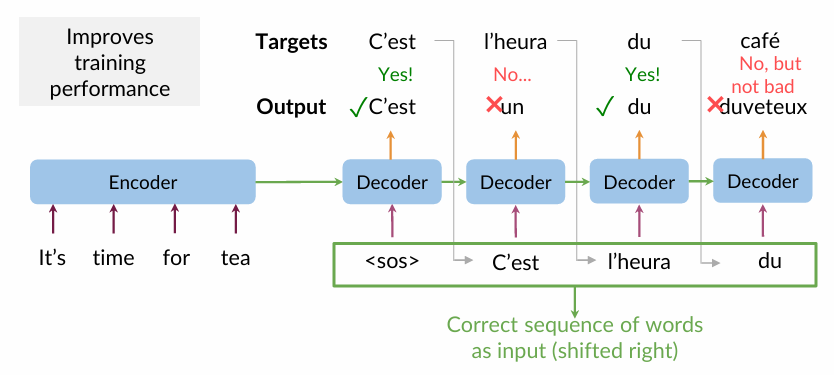

**During Inference:** Ground-truth is not available, so use autoregression to generate decoder output. (*realistic inference scenario*)
- **Disadvantage**: Errors can accumulate.

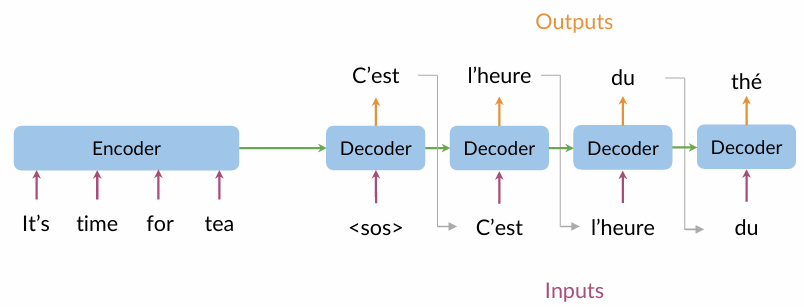


### Evaluation Metrics for Machine Translation

#### 1. BLEU Score (Bilingual Evaluation Understudy)

**Definition**: Compares candidate translations to reference (human) translations

**Score Range**: 0 to 1 (or 0 to 100)
- **Closer to 1**: Better translation
- **0**: No words match reference

**BLEU computes how many words from candidate appear in reference.**


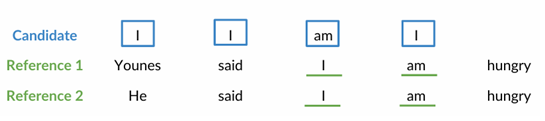

- Count each matched word occurrence **at most once**
- Match Count: I (1) + am (1) = 2
- Total words in candidate: 4
- Precision: 2/4 = 0.5


### BLEU Score Limitations

- BLEU Doesn't consider semantic meaning and sentence structure
   - Candidate 1: "Ate I was hungry because!" (BLEU = 0.5)
   - Candidate 2:"I was hungry because I ate" (BLEU = 0.5)
   - Same BLEU, but second is grammatically correct

- BLEU requires exact word matches so for synonyms BLEU score may be different
   - "big" vs "large"
   - "beautiful" vs "pretty"

- BLEU is used as an industry standard because it is quick to compute and it enables easy comparison between models


### Evaluation Metrics for Machine Translation

#### 2. ROUGE-N (Recall-Oriented Understudy for Gisting Evaluation) Score

- Compares candidates with reference translations for various values of $N$

   - **ROUGE-1 (Unigram)**: Uses ($N = 1$) (individual words). It measures basic word overlap (vocabulary choice and retention).
   - **ROUGE-2 (Bigram)**: Uses ($N = 2$) (two-word sequences). It measures how well the model preserves short phrases and basic word order.
   - **ROUGE-3+ (Trigrams/etc.)**: Uses ($N \ge 3$). It measures longer phrase overlaps and grammatical flow.

For higher $N$ values, the model must successfully reproduce longer strings of exact, consecutive words.


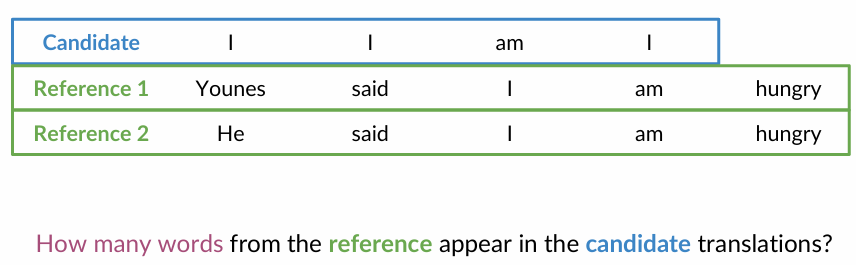






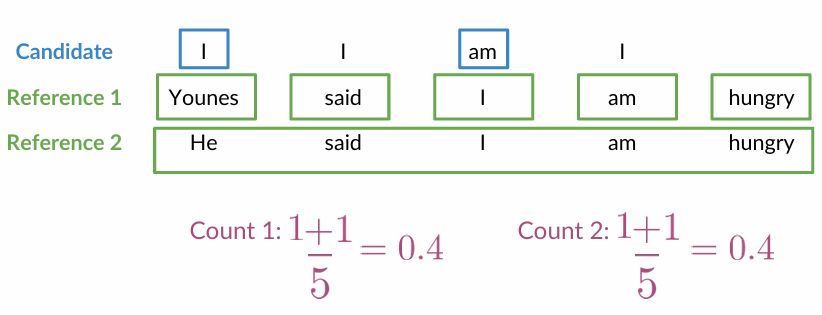

### ROUGE-N vs BLEU

```
ROUGE-N (Recall-based):
  Q: How many reference words appear in candidate?
  
  Candidate:   [I, l, am, l]
  Reference 1: [Younes, said, I, am, hungry]
  
  Match count: 2 (I, am)
  Reference count: 5
  ROUGE = 2/5 = 0.4 ← Lower recall (missing words)

BLEU (Precision-based):
  Q: How many candidate words match references?
  
  Candidate:   [I, l, am, l]
  Reference 1: [Younes, said, I, am, hungry]
  
  Match count: 2 (I, am)
  Candidate count: 4
  BLEU = 2/4 = 0.5 ← Higher precision (but extra wrong words)
```

**Key Difference:**
- **BLEU**: Precision - "How much of what we generated is correct?"
- **ROUGE-N**: Recall - "How much of the reference do we capture?"

**Combined F1 Score:**


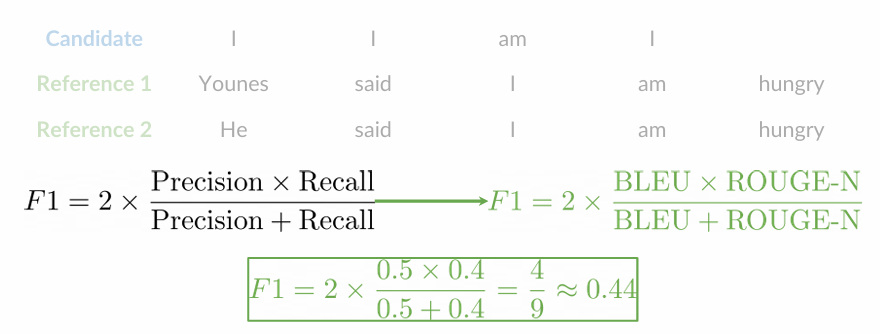

### Sampling and Decoding Strategies

```
After Decoder Processing:

Words:   de   la   le   et   à   ...
P(wi):  0.02  0.04  0.1  0.005  0.08  ...

Softmax output gives probability distribution
over all words in target vocabulary

Now: How do we choose which word to generate?
```

#### 1. Greedy Decoding

**Strategy**: Select the most probable word at each step

```
Step 1: Select le (highest probability = 0.1)
Step 2: Select et (highest probability from next output)
Step 3: Continue...
Output: "le et... something"

**Problem**:
   - Best word at each step ≠ best overall sequence
   - Myopic (short-sighted) strategy
   - Can get stuck in local optima
   
Example:
  Step 1: "le" (0.1) vs "a" (0.08) → Choose "le"
  Step 2: Given "le", next word has low probability
         Could have been better with "a" in step 1
```

**When to use**: Quick inference, low latency requirements

### 2. Random Sampling

**Strategy**: Sample words according to probability distribution

```
Example:

Step 1 probabilities:
  Word "am":      0.05
  Word "full":    0.3
  Word "hungry":  0.15
  Word "l":       0.25
  Word "the":     0.25

Probability distribution (like a weighted die)
┌──────────────────────────────────────┐
│ "am" │ "full" │ "hungry" │ "l" │ "the" │
│0.05  │ 0.3  │  0.15   │0.25│ 0.25  │
└──────────────────────────────────────┘

Roll the die: could get any word!
  Roll 1: "full" (0.3 probability)
  Roll 2: "l" (0.25 probability)
  Roll 3: "the" (0.25 probability)
  
❌ Problems:
   - Often too random for accurate translation
   - Generates grammatically incorrect sequences
   - High variance in output quality
   
✓ Benefits:
   - Diverse outputs
   - Explores different hypotheses
```

### Temperature in Sampling

**Temperature Parameter**: Controls randomness in sampling

```
Original Probabilities:
  Word "am":      0.05
  Word "full":    0.3
  Word "hungry":  0.15
  Word "l":       0.25
  Word "the":     0.25

───────────────────────────────────────────────────────────────

Low Temperature (T = 0.5):
  "This word is very likely correct. Yawn."
  
  More confident, conservative network
  ┌──────────────────────────────────────┐
  │ "am" │ "full" │ "hungry" │ "l" │ "the" │
  │0.01  │ 0.58  │  0.14   │0.15│ 0.12  │
  └──────────────────────────────────────┘
  
  Probabilities are MORE extreme
  High probability words → even more likely
  
───────────────────────────────────────────────────────────────

High Temperature (T = 2.0):
  "Omg, but what if it's this super random word?"
  
  More random, exploratory network
  ┌──────────────────────────────────────┐
  │ "am" │ "full" │ "hungry" │ "l" │ "the" │
  │0.18  │ 0.20  │  0.21   │0.21│ 0.20  │
  └──────────────────────────────────────┘
  
  Probabilities are MORE uniform
  All words roughly equally likely
```

### 3. Beam Search: The Better Strategy

```
Most Probable Translation ≠ One with Most Probable Word at Each Step

Solution: Calculate probability of multiple possible sequences
          Beam search ("beam width B determines sequences we keep")

Beam Search with B=2:

Step 1:
  Probability of "I":   0.5
  Probability of "am":  0.4
  (Keep top 2: "I" and "am")

Step 2:
  From "I", next word:
    "I am":      P(I) × P(am|I) = 0.5 × 0.5 = 0.25 ✓
    "I hungry": P(I) × P(hungry|I) = 0.5 × 0.3 = 0.15
    
  From "am", next word:
    "am I":     P(am) × P(I|am) = 0.4 × 0.7 = 0.28 ✓ ← Higher!
    "am hungry": P(am) × P(hungry|am) = 0.4 × 0.05 = 0.02
  
  (Keep top 2 overall: "am I" and "I am")

Step 3:
  Continue from both...
  
Final: Select sequence with highest probability
       "am I" usually wins because "am I" has higher
       joint probability than "I am"
```

### Beam Search Example

```
B = 2 (Keep top 2 sequences at each step)

Initial:

P(w₁ | "<sos>")
    I:      0.5
    am:     0.4
    very:   0.05
    hungry: 0.03
    now:    0.02
    
Top 2: "I" (0.5), "am" (0.4)

═══════════════════════════════════════════════════

Step 2:

From "I":
  P(w₂ | "I")
    I:      0.1
    am:     0.5  ← "I am": 0.5 × 0.5 = 0.25 ✓
    very:   0.2
    hungry: 0.15
    now:    0.05

From "am":
  P(w₂ | "am")
    I:      0.05
    am:     0.1
    very:   0.3
    hungry: 0.5  ← "am hungry": 0.4 × 0.5 = 0.20
    now:    0.05

All candidates:
  "I am":      0.5 × 0.5 = 0.25   ✓
  "am I":      0.4 × 0.05 = 0.02
  "I very":    0.5 × 0.2 = 0.10
  "I hungry":  0.5 × 0.15 = 0.075
  "am very":   0.4 × 0.3 = 0.12
  "am hungry": 0.4 × 0.5 = 0.20   ✓ (Actually, let's reconsider...)
  ... (and so on)

Top 2 overall: "I am" (0.25), "am hungry" (0.20)
```

**Key Insight**: "am hungry" vs "I am" comparison
- "I am" started with highest probability but "am hungry" caught up
- This shows the power of considering full sequences
- Greedy search would have stuck with "I"

### Problems with Beam Search


1. **Beam Search may penalize long sequences**
- **Example:**
   - Sequence 1: "I am hungry"
  $$P(S1) = 0.5 × 0.4 × 0.3 = 0.06$$
    
   - Sequence 2: "I am very"
  $$P(S2) = 0.5 × 0.4 × 0.8 = 0.16$$
  Even though Sequence 1 is better semantically,
  Sequence 2 has higher probability!
  
   - **Solution**: Normalize by sequence length
      - Normalized $P(S1) = 0.06 / 3 = 0.02$
      - Normalized $P(S2) = 0.16 / 3 = 0.053$
    - It still favors $S2$, but less extremely

2. **Beam Search is computationally expensive**

- With Beam Width $B$ and Vocabulary Size $V$:
   - Each step: $O(B × V)$ operations
   - Total: $O(T × B × V)$ where $T$ = sequence length
   - For $B=10, V=50,000, T=30:$
$$30 × 10 × 50,000 = 15 \text{million operations}$$
  

### Summary and Key Takeaways

1. **Basic Seq2Seq**:
   - Simple but suffers from information bottleneck
   - Can't handle long sequences well

2. **Seq2Seq with Attention**:
   - Solves bottleneck by giving decoder access to all encoder states
   - Dynamically learns which parts to focus on
   - Better performance on longer sequences

3. **Query-Key-Value Framework**:
   - Provides elegant mathematical formulation
   - Enables scaled dot-product attention
   - Foundation for Transformer architecture

#### Training Techniques
- **Teacher Forcing**: Ground truth during training
- **Curriculum Learning**: Start with easier examples
- **Error propagation**: Early mistakes compound

#### Evaluation
- **BLEU**: Precision-based, quick to compute
- **ROUGE**: Recall-based, captures coverage
- **F1**: Harmonic mean of precision and recall

#### Decoding Strategies
- **Greedy**: Fast but myopic
- **Random Sampling**: Diverse but often wrong
- **Beam Search**: Best tradeoff (B=3-5 typical)


### Implementation of Main Concepts Covered in this Notebook

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###########################################
# Example: Attention mechanism computation
# Query, Key, Value vectors for attention
###########################################

# Sample encoder hidden states (4 words, 3 dimensions)
h1 = np.array([0.3, 0.1, 0.2])  # "It's"
h2 = np.array([0.2, -0.7, 0.9])  # "time"
h3 = np.array([1.3, 0.3, 0.8])  # "for"
h4 = np.array([-0.4, 0.6, -1.1])  # "tea"

# Stack into matrix (Keys and Values are the same as encoder states)
K = np.array([h1, h2, h3, h4])  # Keys: (4, 3)
V = np.array([h1, h2, h3, h4])  # Values: (4, 3)

# Query from decoder (1, 3)
Q = np.array([[0.5, -0.2, 0.8]])  # Decoder state looking at what to translate

# Step 1: Compute scores (Q @ K^T)
d_k = K.shape[1]  # dimension of keys
scores = Q @ K.T / np.sqrt(d_k)  # Scaled dot-product

print("Attention Scores:")
print(f"Q @ K^T / sqrt(d_k) = {scores}")
print()

# Step 2: Apply softmax
exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))  # Numerical stability
attention_weights = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

print("Attention Weights (after softmax):")
print(f"[It's, time, for, tea] = {attention_weights[0]}")
print(f"Sum of weights = {np.sum(attention_weights[0])}")
print()

# Step 3: Compute context vector (weighted sum of values)
context_vector = attention_weights @ V

print("Context Vector (weighted combination of values):")
print(f"c = {context_vector[0]}")
print()

# Visualization
words = ['It\'s', 'time', 'for', 'tea']
plt.figure(figsize=(10, 6))
plt.bar(words, attention_weights[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.ylabel('Attention Weight', fontsize=12)
plt.xlabel('Input Words', fontsize=12)
plt.title('Attention Weights for Generating "du" (French: "of the")', fontsize=14)
plt.ylim([0, max(attention_weights[0]) * 1.2])
for i, w in enumerate(attention_weights[0]):
    plt.text(i, w + 0.02, f'{w:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('/tmp/attention_weights.png', dpi=100, bbox_inches='tight')
print("Visualization saved!")
plt.show()


###########################################
# Example: Teacher forcing vs. autoregressive decoding

# Simulated decoder predictions (probabilities for next word)
# Words: <sos>, C'est, l'heure, du, thé, <eos>
###########################################

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()

# Step 1 decoder output: which word to pick?
step1_logits = np.array([0.1, 2.5, 0.2, 0.3, 0.1, 0.1])
step1_probs = softmax(step1_logits)
step1_pred = np.argmax(step1_probs)
words = ['<sos>', "C'est", "l'heure", "du", "thé", "<eos>"]

print("Step 1 Prediction:")
print(f"Logits: {step1_logits}")
print(f"Probabilities: {step1_probs}")
print(f"Predicted word index: {step1_pred} -> {words[step1_pred]}")
print(f"Target: {words[1]}")
print()

# Teacher forcing input for step 2
print("Teacher Forcing Input for Step 2: C'est (ground truth)")
print()

# Autoregressive input for step 2 (uses prediction from step 1)
print(f"Autoregressive Input for Step 2: {words[step1_pred]} (predicted)")
print()

# If prediction was wrong, this affects all subsequent steps
if step1_pred != 1:  # 1 is index for "C'est"
    print("⚠️ Mismatch detected!")
    print("This wrong input will propagate errors to steps 2, 3, 4...")
else:
    print("✓ Prediction correct!")



#####################################
# BLEU Score Calculation
#####################################


from collections import Counter
from math import log, exp

def calculate_bleu(candidate, references, max_n=4):
    """
    Calculate BLEU score

    Args:
        candidate: List of words in candidate translation
        references: List of lists - multiple reference translations
        max_n: Maximum n-gram size (1-gram, 2-gram, etc.)

    Returns:
        BLEU score (0 to 1)
    """

    def get_ngrams(tokens, n):
        """Extract n-grams from token list"""
        return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    # Brevity penalty for short translations
    candidate_length = len(candidate)
    reference_lengths = [len(ref) for ref in references]
    closest_ref_length = min(reference_lengths, key=lambda x: abs(x - candidate_length))

    if candidate_length > closest_ref_length:
        brevity_penalty = 1.0
    else:
        brevity_penalty = exp(1 - closest_ref_length / candidate_length) if candidate_length > 0 else 0

    precisions = []

    # Calculate n-gram precisions
    for n in range(1, max_n + 1):
        if len(candidate) < n:
            precisions.append(0)
            continue

        candidate_ngrams = get_ngrams(candidate, n)

        # Find maximum count in any reference
        max_counts = Counter()
        for reference in references:
            reference_ngrams = get_ngrams(reference, n)
            for ngram in reference_ngrams:
                max_counts[ngram] = max(max_counts[ngram], reference_ngrams.count(ngram))

        # Count matches
        candidate_counts = Counter(candidate_ngrams)
        matches = sum(min(candidate_counts[ngram], max_counts[ngram])
                      for ngram in candidate_counts)

        precision = matches / len(candidate_ngrams) if candidate_ngrams else 0
        precisions.append(precision)

    # Geometric mean of precisions
    if any(p == 0 for p in precisions):
        return 0  # If any n-gram precision is 0, BLEU = 0

    log_precisions = [log(p) for p in precisions]
    geo_mean = exp(sum(log_precisions) / len(log_precisions))

    bleu = geo_mean * brevity_penalty
    return bleu

# Example from slides
candidate = ["I", "l", "am", "l"]
reference1 = ["Younes", "said", "I", "am", "hungry"]
reference2 = ["He", "said", "I", "am", "hungry"]
references = [reference1, reference2]

bleu_score = calculate_bleu(candidate, references)
print(f"Candidate: {' '.join(candidate)}")
print(f"Reference 1: {' '.join(reference1)}")
print(f"Reference 2: {' '.join(reference2)}")
print()
print(f"BLEU Score: {bleu_score:.4f}")
print()

# Example 2: Better translation
candidate2 = ["I", "am", "hungry"]
bleu_score2 = calculate_bleu(candidate2, references)
print(f"\nCandidate 2: {' '.join(candidate2)}")
print(f"BLEU Score: {bleu_score2:.4f}")
print()

# Example 3: Perfect translation match
candidate3 = ["He", "said", "I", "am", "hungry"]
bleu_score3 = calculate_bleu(candidate3, references)
print(f"\nCandidate 3: {' '.join(candidate3)}")
print(f"BLEU Score: {bleu_score3:.4f}")


#####################################
# ROUGE-N Score Calculation
#####################################


def calculate_rouge_n(candidate, references, n=1):
    """
    Calculate ROUGE-N score (Recall based)

    Args:
        candidate: List of words in candidate translation
        references: List of lists - multiple reference translations
        n: n-gram size

    Returns:
        ROUGE-N score
    """

    def get_ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    rouge_scores = []

    for reference in references:
        ref_ngrams = set(get_ngrams(reference, n))
        cand_ngrams = set(get_ngrams(candidate, n))

        # Find matches
        matches = len(ref_ngrams & cand_ngrams)  # Intersection
        recall = matches / len(ref_ngrams) if len(ref_ngrams) > 0 else 0

        rouge_scores.append(recall)

    # Return average across references
    return np.mean(rouge_scores) if rouge_scores else 0

# Example from slides
candidate = ["I", "l", "am", "l"]
reference1 = ["Younes", "said", "I", "am", "hungry"]
reference2 = ["He", "said", "I", "am", "hungry"]
references = [reference1, reference2]

rouge_n = calculate_rouge_n(candidate, references, n=1)

print("ROUGE-N Score Calculation")
print(f"Candidate: {' '.join(candidate)}")
print(f"Reference 1: {' '.join(reference1)}")
print(f"Reference 2: {' '.join(reference2)}")
print()
print(f"ROUGE-1 Score: {rouge_n:.4f}")
print()
print("Interpretation:")
print(f"On average, {rouge_n*100:.1f}% of reference words appear in candidate")
print()

# Example 2: Better translation
candidate2 = ["He", "said", "I", "am", "hungry"]
rouge_n2 = calculate_rouge_n(candidate2, references, n=1)
print(f"\nCandidate 2: {' '.join(candidate2)}")
print(f"ROUGE-1 Score: {rouge_n2:.4f}")


#####################################
# F1 Score combining BLEU and ROUGE-N
#####################################

def calculate_f1(bleu, rouge):
    """Calculate F1 score from BLEU and ROUGE"""
    if bleu + rouge == 0:
        return 0
    return 2 * (bleu * rouge) / (bleu + rouge)

bleu = 0.5
rouge = 0.4
f1 = calculate_f1(bleu, rouge)

print(f"BLEU Score:  {bleu:.4f}")
print(f"ROUGE Score: {rouge:.4f}")
print(f"F1 Score:    {f1:.4f}")
print()
print("Interpretation:")
print(f"BLEU (Precision): {bleu*100:.1f}% of generated words are correct")
print(f"ROUGE (Recall): {rouge*100:.1f}% of reference content is captured")
print(f"F1 (Harmonic Mean): {f1:.4f}")

#####################################
# Greedy Decoding Example
#####################################


import numpy as np

def greedy_decoding(output_probabilities, vocab):
    """
    Greedy decoding: select highest probability word at each step

    Args:
        output_probabilities: List of probability distributions
        vocab: List of words in vocabulary

    Returns:
        Generated sequence
    """

    generated_sequence = []

    for probs in output_probabilities:
        # Select word with highest probability
        best_word_idx = np.argmax(probs)
        best_word = vocab[best_word_idx]
        best_prob = probs[best_word_idx]

        generated_sequence.append((best_word, best_prob))

    return generated_sequence

# Example: Seq2Seq decoder outputs (probabilities for target language words)
words = ['de', 'la', 'le', 'et', 'à', 'un', 'une']

# Step 1 output probabilities
step1_probs = np.array([0.02, 0.04, 0.1, 0.005, 0.08, 0.5, 0.25])

# Step 2 output probabilities (given step1)
step2_probs = np.array([0.7, 0.1, 0.05, 0.05, 0.05, 0.02, 0.03])

# Step 3 output probabilities (given step1, step2)
step3_probs = np.array([0.05, 0.06, 0.65, 0.1, 0.08, 0.03, 0.03])

output_probs = [step1_probs, step2_probs, step3_probs]

sequence = greedy_decoding(output_probs, words)

print("Greedy Decoding Example:")
print()
for i, (word, prob) in enumerate(sequence, 1):
    print(f"Step {i}: Selected '{word}' (probability: {prob:.3f})")
    # Show alternatives
    top_indices = np.argsort(output_probs[i-1])[-3:][::-1]
    print(f"  Top 3 options: {[(words[idx], f'{output_probs[i-1][idx]:.3f}') for idx in top_indices]}")
    print()

generated = ' '.join([w for w, _ in sequence])
print(f"Generated sequence: {generated}")



#####################################
# Random Sampling Example
#####################################


def random_sampling(output_probabilities, vocab, num_samples=3):

    all_sequences = []

    for sample in range(num_samples):
        sequence = []

        for step, probs in enumerate(output_probabilities):

            probs = probs / np.sum(probs)  # <-- added line

            word_idx = np.random.choice(len(vocab), p=probs)
            word = vocab[word_idx]
            prob = probs[word_idx]

            sequence.append((word, prob))

        all_sequences.append(sequence)

    return all_sequences

# Example: Same as before
words = ['de', 'la', 'le', 'et', 'à', 'un', 'une']
step1_probs = np.array([0.02, 0.04, 0.1, 0.005, 0.08, 0.5, 0.25])
step2_probs = np.array([0.7, 0.1, 0.05, 0.05, 0.05, 0.02, 0.03])
step3_probs = np.array([0.05, 0.06, 0.65, 0.1, 0.08, 0.03, 0.03])

output_probs = [step1_probs, step2_probs, step3_probs]

# Generate multiple samples
np.random.seed(42)
sampled_sequences = random_sampling(output_probs, words, num_samples=3)

print("Random Sampling Results (3 different samples):")
print()

for sample_num, sequence in enumerate(sampled_sequences, 1):
    generated = ' '.join([w for w, _ in sequence])
    prob_product = np.prod([p for _, p in sequence])
    print(f"Sample {sample_num}: '{generated}'")
    print(f"  Sequence probability: {prob_product:.6f}")
    print()




#####################################
# Temperature Effect on Probabilities
#####################################

def apply_temperature(logits, temperature=1.0):
    """
    Apply temperature to logits and compute softmax

    Args:
        logits: Raw neural network outputs
        temperature: Temperature parameter
               < 1.0: More confident/deterministic
               = 1.0: No change
               > 1.0: More random/exploratory

    Returns:
        Probability distribution
    """
    scaled_logits = logits / temperature
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))  # Numerical stability
    return exp_logits / np.sum(exp_logits)

# Example logits from decoder
logits = np.array([0.5, 1.2, 0.8, 0.3, 0.1])  # Raw outputs
words = ["I", "am", "very", "hungry", "now"]

# Different temperatures
temperatures = [0.5, 1.0, 2.0]
probabilities = [apply_temperature(logits, t) for t in temperatures]

print("Effect of Temperature on Probability Distribution")
print()
print(f"{'Word':<10} {'T=0.5':<10} {'T=1.0':<10} {'T=2.0':<10}")
print("="*40)

for i, word in enumerate(words):
    prob_values = [prob[i] for prob in probabilities]
    print(f"{word:<10} {prob_values[0]:<10.4f} {prob_values[1]:<10.4f} {prob_values[2]:<10.4f}")

print()
print("Analysis:")
print(f"T=0.5  (Low):  High confidence, peaked distribution. Usually chooses 'am'")
print(f"T=1.0  (Base): Original distribution from model")
print(f"T=2.0  (High): More uniform, random exploration possible")


#####################################
# Beam Search Example
#####################################

class BeamSearchDecoder:
    def __init__(self, beam_width=2):
        self.beam_width = beam_width

    def decode(self, probabilities, vocab, max_steps=None):
        """
        Perform beam search decoding

        Args:
            probabilities: List of probability distributions at each step
            vocab: List of words in vocabulary
            max_steps: Maximum decoding steps

        Returns:
            List of (sequence, total_probability) tuples
        """
        if max_steps is None:
            max_steps = len(probabilities)

        # Initialize: first step
        top_k_indices = np.argsort(probabilities[0])[-self.beam_width:][::-1]
        beams = [
            ([vocab[i]], probabilities[0][i])
            for i in top_k_indices
        ]

        # Decode remaining steps
        for step in range(1, max_steps):
            all_candidates = []

            # For each beam, generate candidates
            for sequence, seq_prob in beams:
                # Get probabilities for this step
                step_probs = probabilities[step]

                # Find top k words
                top_k_indices = np.argsort(step_probs)[-self.beam_width:][::-1]

                for word_idx in top_k_indices:
                    word = vocab[word_idx]
                    word_prob = step_probs[word_idx]
                    total_prob = seq_prob * word_prob

                    new_sequence = sequence + [word]
                    all_candidates.append((new_sequence, total_prob))

            # Select top beam_width candidates
            all_candidates.sort(key=lambda x: x[1], reverse=True)
            beams = all_candidates[:self.beam_width]

        return beams

# Example
words = ['I', 'am', 'very', 'hungry', 'now']

# Step 1: Probability distribution over first word
step1_probs = np.array([0.5, 0.4, 0.05, 0.03, 0.02])

# Step 2: Probability distribution given different previous words
step2_probs_given_I = np.array([0.1, 0.5, 0.2, 0.15, 0.05])      # P(word | "I")
step2_probs_given_am = np.array([0.05, 0.1, 0.3, 0.5, 0.05])     # P(word | "am")

# For simplicity, use fixed step 2 probabilities
step2_probs = np.array([0.1, 0.2, 0.25, 0.35, 0.1])

# Step 3
step3_probs = np.array([0.05, 0.1, 0.2, 0.4, 0.25])

all_probs = [step1_probs, step2_probs, step3_probs]

# Beam search with beam width 2
decoder = BeamSearchDecoder(beam_width=2)
results = decoder.decode(all_probs, words, max_steps=3)

print("Beam Search Results (Beam Width = 2):")
print()
for rank, (sequence, prob) in enumerate(results, 1):
    sequence_str = ' '.join(sequence)
    print(f"Rank {rank}: '{sequence_str}'")
    print(f"  Probability: {prob:.6f}")
    print()



#####################################
# Final Comprehensive Example: Full NMT Pipeline
#####################################


print("="*70)
print("NEURAL MACHINE TRANSLATION WITH ATTENTION")
print("="*70)
print()

print("Step 1: Input Preparation")
print("-" * 70)
english_sentence = "It's time for tea"
tokenized = english_sentence.split()
print(f"Input sentence: {english_sentence}")
print(f"Tokenized: {tokenized}")
print()

print("Step 2: Encoding")
print("-" * 70)
print("Encoder processes: It's → time → for → tea")
print("Produces hidden states: h1, h2, h3, h4")
print()

print("Step 3: Decoding with Attention")
print("-" * 70)
print("Decoder starts with context vector h4")
print("For each output word, attention mechanism:")
print("  1. Computes how relevant each input word is")
print("  2. Creates weighted combination (context vector)")
print("  3. Uses context to generate output word")
print()

print("Step 4: Generation Process")
print("-" * 70)
output_words = ["C'est", "l'heure", "du", "thé"]
attention_weights_examples = [
    ("C'est", [0.1, 0.1, 0.3, 0.5]),   # Focuses on "tea"
    ("l'heure", [0.2, 0.7, 0.05, 0.05]),  # Focuses on "time"
    ("du", [0.1, 0.05, 0.8, 0.05]),    # Focuses on "for"
    ("thé", [0.05, 0.1, 0.1, 0.75])    # Focuses on "tea"
]

for word, weights in attention_weights_examples:
    print(f"\nGenerating '{word}':")
    print(f"  Attention focus:")
    for input_word, weight in zip(tokenized, weights):
        print(f"    {input_word:8} → {weight:.2f} ({int(weight*100)}%)")
print()

print("Step 5: Evaluation")
print("-" * 70)
candidate = output_words
reference = ["C'est", "l'heure", "du", "thé"]

print(f"Candidate: {' '.join(candidate)}")
print(f"Reference: {' '.join(reference)}")
print()

if candidate == reference:
    print("✓ Perfect match!")
    print(f"  BLEU Score: 1.0000")
    print(f"  ROUGE Score: 1.0000")
else:
    print("× Differences detected")
print()

print("="*70)
print("KEY INNOVATIONS DEMONSTRATED:")
print("="*70)
print("1. Attention Mechanism: Focuses on relevant input words")
print("2. Query-Key-Value: Mathematical framework for attention")
print("3. Dynamic Focus: Different input words for different outputs")
print("4. No Bottleneck: Full access to encoder information")
print("5. Interpretability: Attention weights show alignment")

